In [66]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg
import scipy.stats as stats

# Project 1

## Part 1
### Q1

In [67]:
P = np.array([[0.9915, 0.005, 0.0025, 0, 0.001],[0,0.986, 0.005, 0.004, 0.005],[0, 0, 0.992, 0.003, 0.005],[0, 0, 0, 0.991, 0.009],[0, 0, 0, 0, 1]])
P

array([[0.9915, 0.005 , 0.0025, 0.    , 0.001 ],
       [0.    , 0.986 , 0.005 , 0.004 , 0.005 ],
       [0.    , 0.    , 0.992 , 0.003 , 0.005 ],
       [0.    , 0.    , 0.    , 0.991 , 0.009 ],
       [0.    , 0.    , 0.    , 0.    , 1.    ]])

In [68]:
sim_runs = 1000
states = []
ts = []
reappearences = 0
state_120_counts = np.zeros(5)
for _ in range(sim_runs):
    state = 0
    t = 0
    local_reappearence = False
    while state != 4:
        state = np.random.choice(5, p=P[state])
        states.append(state)
        t += 1
        if state == 1 or state == 3:
            local_reappearence = True
        if t == 120:
            state_120_counts[state] += 1
    if local_reappearence:
        reappearences += 1
    ts.append(t)


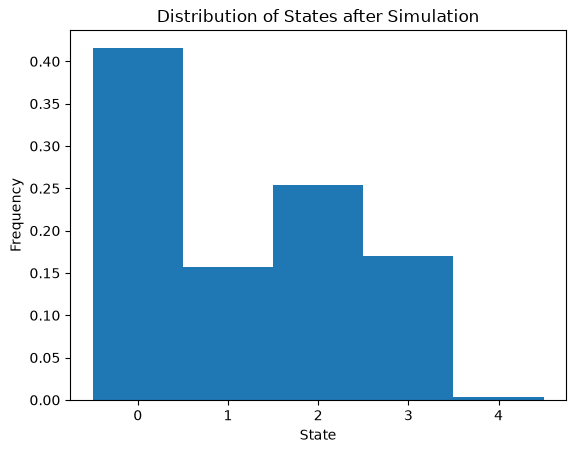

In [69]:
plt.hist(states, bins=np.arange(-0.5, 5.5, 1), density=True)
plt.xlabel('State')
plt.ylabel('Frequency')
plt.title('Distribution of States after Simulation')
plt.xticks(range(5))
plt.show()

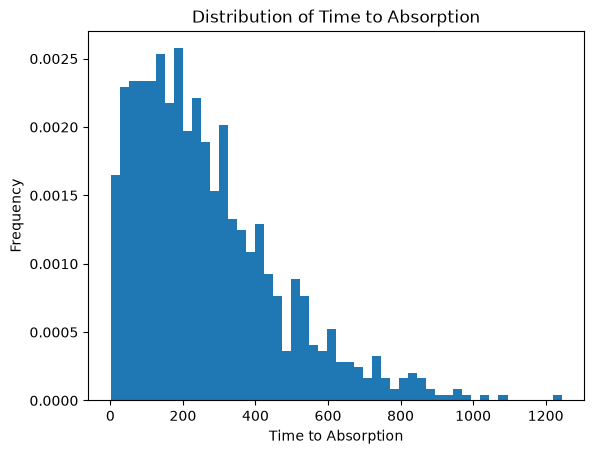

In [70]:
plt.hist(ts, bins=50, density=True)
plt.xlabel('Time to Absorption')
plt.ylabel('Frequency')
plt.title('Distribution of Time to Absorption')
plt.show()

### Q2

In [71]:
reappearence_prob = reappearences / sim_runs
print(f'Estimated Probability of Reappearance: {reappearence_prob:.4f}')

Estimated Probability of Reappearance: 0.6850


In [72]:
#Expected prob mass at step 120
state_dist = np.zeros(5)
state_dist[0] = 1
for _ in range(120):
    state_dist = state_dist @ P
print(f'Expected Probability Mass at Step 120: {state_dist}')

Expected Probability Mass at Step 120: [0.35902627 0.15895604 0.1660869  0.06774149 0.2481893 ]


In [73]:
state_120_probs = state_120_counts / sim_runs
state_120_probs[4] = 1 - np.sum(state_120_probs[:4]) #Correction for states that ended prior to reaching step 120
print(f'Empirical Probability Mass at Step 120: {state_120_probs}')

Empirical Probability Mass at Step 120: [0.337 0.151 0.176 0.074 0.262]


In [74]:
stats.chisquare(state_120_probs, f_exp=state_dist ) # Seems pretty close, p-value is 0.9999

Power_divergenceResult(statistic=np.float64(0.0036879212234719808), pvalue=np.float64(0.999998301993126))

### Q3

In [75]:
def phase_type_pdf(pi, Ps, ps, t) -> float:
    return float(pi.T @ np.linalg.matrix_power(Ps, t) @ ps)

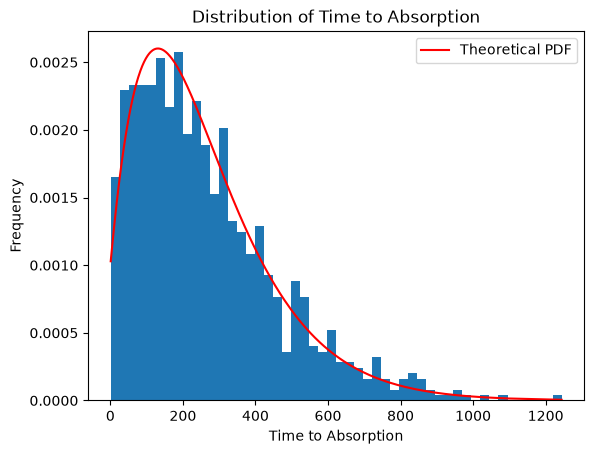

In [76]:
plt.hist(ts, bins=50, density=True)
plt.plot(sorted(ts), [phase_type_pdf(np.array([1, 0, 0, 0]), P[:4,:4], P[:4,4], t) for t in sorted(ts)], color='red', label='Theoretical PDF')
plt.xlabel('Time to Absorption')
plt.ylabel('Frequency')
plt.title('Distribution of Time to Absorption')
plt.legend()
plt.show()

In [77]:
count = 0
survival_times = []
while count < 1000:
    state = 0
    t = 0
    relevant = False
    while state != 4:
        state = np.random.choice(5, p=P[state])
        t += 1
        if state > 0 and state < 4 and not relevant and t <= 12:
            relevant = True
    if relevant:
        survival_times.append(t)
        count += 1


In [78]:
mean_survival_time = np.mean(survival_times)
print(f'Estimated Mean Survival Time (Conditioned on Reappearance within 12 steps): {mean_survival_time:.4f}')

Estimated Mean Survival Time (Conditioned on Reappearance within 12 steps): 172.8740


### Q5

In [79]:
def run_sim()-> tuple:
    lifetimes = []
    for i in range(200):
        state = 0
        t = 0
        while state != 4:
            state = np.random.choice(5, p=P[state])
            t += 1
        lifetimes.append(t)
    return np.mean(lifetimes), np.sum(np.array(lifetimes) > 350)/200

In [80]:
means, probs = [], []
for _ in range(100):
    mean, prob = run_sim()
    means.append(mean)
    probs.append(prob)

mc_mean = np.mean(means)
print(f'Monte Carlo Estimated Mean Time to Absorption: {mc_mean:.4f}')
print(f'Monte Carlo Estimated Probability of Absorption Time > 350: {np.mean(probs):.4f}')
print(f'Variance of Estimated Probability: {np.var(probs):.6f}')

Monte Carlo Estimated Mean Time to Absorption: 262.8248
Monte Carlo Estimated Probability of Absorption Time > 350: 0.2648
Variance of Estimated Probability: 0.000788


In [81]:
c = -np.cov(means, probs)[0, 1]/np.var(means)
y = np.array(probs) + c * (np.array(means) - mc_mean)
adjusted_prob = np.mean(y)
print(f'Adjusted Probability of Absorption Time > 350 using Control Variate: {adjusted_prob:.4f}')
print(f'Variance with Control Variate: {np.var(y):.6f}')

Adjusted Probability of Absorption Time > 350 using Control Variate: 0.2648
Variance with Control Variate: 0.000304


## Part 2
### Q7

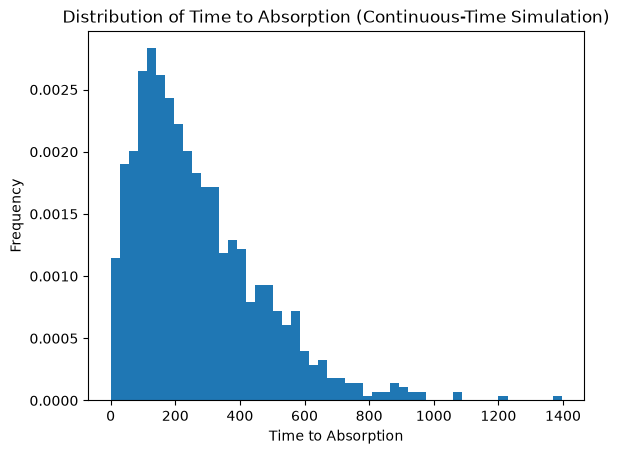

In [82]:
Q = np.array([[-0.0085, 0.005, 0.0025, 0, 0.001],[0, -0.014, 0.005, 0.004, 0.005],[0, 0, -0.008, 0.003, 0.005],[0, 0, 0, -0.009, 0.009],[0, 0, 0, 0, 0]])
states = []
ts = []
distant_reappearences = 0
for _ in range(1000):
    state = 0
    t = 0
    while state != 4:
        time_to_next = stats.expon.rvs(scale=-1/Q[state, state])
        if (t + time_to_next > 30.5 and t < 30.5) and (state == 2 or state == 3):
            distant_reappearences += 1
        t += time_to_next  
        transition_probs = Q[state] / -Q[state, state]
        # Remove probability of self-transition, and backwards transitions
        transition_probs[state] = 0
        transition_probs[:state] = 0
        transition_probs /= transition_probs.sum() # Renormalize
        state = np.random.choice(5, p=transition_probs)
        states.append(state)
    ts.append(t)
plt.hist(ts, bins=50, density=True)
plt.xlabel('Time to Absorption')
plt.ylabel('Frequency')
plt.title('Distribution of Time to Absorption (Continuous-Time Simulation)')
plt.show()
    

In [83]:
# Report the mean, along with a confidence interval, and the standard deviation, also with a confidence interval.
mean_time = np.mean(ts)
std_time = np.std(ts, ddof=1)
n = len(ts)
confidence_level = 0.95
z_score = stats.norm.ppf(1 - (1 - confidence_level) / 2)
mean_ci_lower = mean_time - z_score * (std_time / np.sqrt(n))
mean_ci_upper = mean_time + z_score * (std_time / np.sqrt(n))
std_ci_lower = std_time * np.sqrt((n - 1) / stats.chi2.ppf(1 - (1 - confidence_level) / 2, n - 1))
std_ci_upper = std_time * np.sqrt((n - 1) / stats.chi2.ppf((1 - confidence_level) / 2, n - 1))
print(f'Mean Time to Absorption: {mean_time:.4f} (95% CI: [{mean_ci_lower:.4f}, {mean_ci_upper:.4f}])')
print(f'Standard Deviation of Time to Absorption: {std_time:.4f} (95% CI: [{std_ci_lower:.4f}, {std_ci_upper:.4f}])')
print(f'Estimated Probability of distant reappearance: {distant_reappearences/1000:.4f}')
print(f'Width of 95% CI for Mean Time to Absorption: {(mean_ci_upper - mean_ci_lower):.4f}')
print(f'Width of 95% CI for Standard Deviation: {(std_ci_upper - std_ci_lower):.4f}')

Mean Time to Absorption: 270.5159 (95% CI: [258.3841, 282.6477])
Standard Deviation of Time to Absorption: 195.7391 (95% CI: [187.5204, 204.7167])
Estimated Probability of distant reappearance: 0.0730
Width of 95% CI for Mean Time to Absorption: 24.2636
Width of 95% CI for Standard Deviation: 17.1963


### Q8

In [84]:
def continuous_phase_type_pdf(p0, Qs, t) -> float:
    q0 = -Qs @ np.ones(Qs.shape[0])
    return float(p0 @ scipy.linalg.expm(Qs * t) @ q0)

In [85]:
def continuous_phase_type_cdf(p0, Qs, t) -> float:
    ones = np.ones(Qs.shape[0])
    return float(1 - p0 @ scipy.linalg.expm(Qs * t) @ ones)

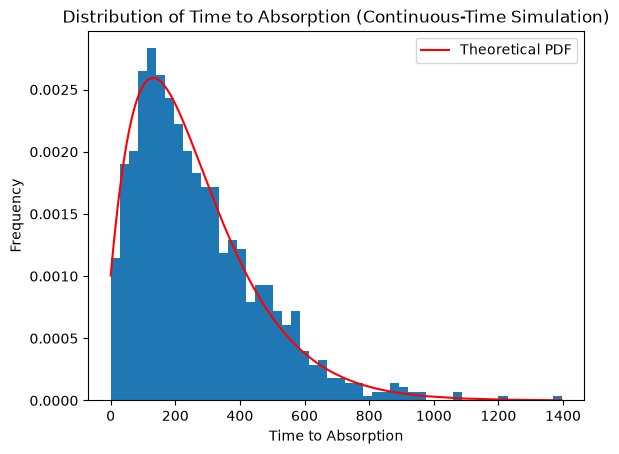

In [86]:
plt.hist(ts, bins=50, density=True)
plt.plot(sorted(ts), [continuous_phase_type_pdf(np.array([1, 0, 0, 0]), Q[:4,:4], t) for t in sorted(ts)], color='red', label='Theoretical PDF')
plt.xlabel('Time to Absorption')
plt.ylabel('Frequency')
plt.title('Distribution of Time to Absorption (Continuous-Time Simulation)')
plt.legend()
plt.show()
    

In [87]:
# statistical test for goodness of fit, using the Kolmogorov-Smirnov test
def cdf(x):
    return np.array([continuous_phase_type_cdf(np.array([1, 0, 0, 0]), Q[:4,:4], t) for t in x])

ks_statistic, p_value = stats.kstest(ts, cdf)
print(f'KS Statistic: {ks_statistic:.4f}, p-value: {p_value:.4f}')

KS Statistic: 0.0250, p-value: 0.5529


### Q9

In [88]:
Q_treatment = np.array([[-0.00475 ,0.0025, 0.00125, 0, 0.001], [0 ,-0.007, 0.002, 0.005, 0],[0, 0, -0.008, 0.003, 0.005], [0,0,0,-0.009,0.009],[0, 0, 0, 0, 0]])
Q_treatment

array([[-0.00475,  0.0025 ,  0.00125,  0.     ,  0.001  ],
       [ 0.     , -0.007  ,  0.002  ,  0.005  ,  0.     ],
       [ 0.     ,  0.     , -0.008  ,  0.003  ,  0.005  ],
       [ 0.     ,  0.     ,  0.     , -0.009  ,  0.009  ],
       [ 0.     ,  0.     ,  0.     ,  0.     ,  0.     ]])

In [89]:
ts_treatment = []
for _ in range(1000):
    state = 0
    t = 0
    while state != 4:
        time_to_next = stats.expon.rvs(scale=-1/Q_treatment[state, state])
        t += time_to_next  
        transition_probs = Q_treatment[state] / -Q_treatment[state, state]
        # Remove probability of self-transition, and backwards transitions
        transition_probs[state] = 0
        transition_probs[:state] = 0
        transition_probs /= transition_probs.sum() # Renormalize
        state = np.random.choice(5, p=transition_probs)
        ts_treatment.append(t)


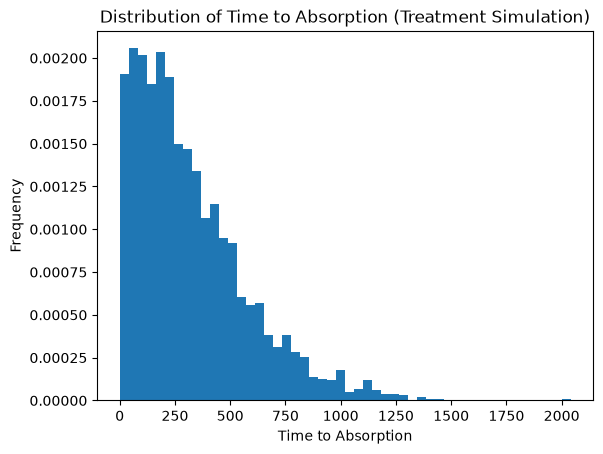

In [90]:
plt.hist(ts_treatment, bins=50, density=True)
plt.xlabel('Time to Absorption')
plt.ylabel('Frequency')
plt.title('Distribution of Time to Absorption (Treatment Simulation)')
plt.show()

In [91]:
# kaplan-meier estimator for the survival function
def kaplan_meier(t, t_list):
    n = len(t_list)
    at_risk = n
    survival_prob = 1.0
    for time in sorted(t_list):
        if time <= t:
            survival_prob *= (at_risk - 1) / at_risk
            at_risk -= 1
        else:
            break
    return survival_prob

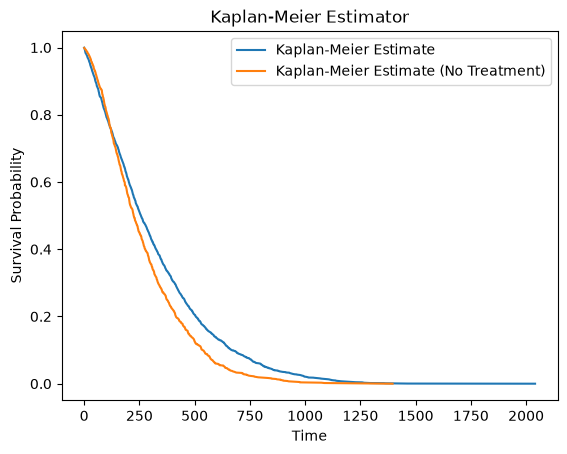

In [92]:
plt.plot(sorted(ts_treatment), [kaplan_meier(t, ts_treatment) for t in sorted(ts_treatment)], label='Kaplan-Meier Estimate')
plt.plot(sorted(ts), [kaplan_meier(t, ts) for t in sorted(ts)], label='Kaplan-Meier Estimate (No Treatment)')
plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.title('Kaplan-Meier Estimator')
plt.legend()
plt.show()

In [93]:
logrank_result = stats.logrank(ts_treatment, ts)
logrank_statistic, logrank_p_value = logrank_result.statistic, logrank_result.pvalue
print(f'Log-Rank Statistic: {logrank_statistic:.4f}, p-value: {logrank_p_value}')

Log-Rank Statistic: -6.3235, p-value: 2.5577851997350654e-10


## Part 3
### Q12

In [94]:
observations = []
for _ in range(1000):
    state = 0
    t = 0
    individual_observations = []
    while state != 4:
        time_to_next = stats.expon.rvs(scale=-1/Q[state, state]) 
        transition_probs = Q[state] / -Q[state, state]
        # Remove probability of self-transition, and backwards transitions
        transition_probs[state] = 0
        transition_probs[:state] = 0
        transition_probs /= transition_probs.sum() # Renormalize
        next_state = np.random.choice(5, p=transition_probs)
        start_window = int(t // 48)
        end_window = int((t + time_to_next) // 48)
        for k in range(start_window, end_window):
            individual_observations.append((k * 48, state))
        state = next_state
        state = next_state
        t += time_to_next

    individual_observations.append((t, state))  # Final observation at absorption
    observations.append(individual_observations)

### Q13

In [95]:
Q0 = np.triu(np.random.rand(5, 5), k=1)
Q0 -= np.diag(Q0.sum(axis=1))
Q0 *= 0.01 # Just to make it a bit better
Q0

array([[-0.0268662 ,  0.00844584,  0.006519  ,  0.00791937,  0.00398199],
       [ 0.        , -0.01701003,  0.00657829,  0.00969444,  0.00073731],
       [ 0.        ,  0.        , -0.01032078,  0.00050821,  0.00981257],
       [ 0.        ,  0.        ,  0.        , -0.00669187,  0.00669187],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ]])

In [96]:
def simulate_interval(Q, y_a, t_a, y_b, t_b, n_states=5, max_attempts=20000):
    """Rejection-sample a CTMC trajectory from (t_a, y_a) to (t_b, y_b) under rate matrix Q."""
    rates = -np.diag(Q)
    for _ in range(max_attempts):
        state, t = y_a, t_a
        jumps = []  # (state, sojourn, next_state), next_state is None for the trailing partial sojourn
        while state != n_states - 1:
            sojourn = np.random.exponential(1 / rates[state])
            if t + sojourn >= t_b:
                jumps.append((state, t_b - t, None))
                break
            probs = Q[state].copy()
            probs[state] = 0
            next_state = np.random.choice(n_states, p=probs / probs.sum())
            jumps.append((state, sojourn, next_state))
            t += sojourn
            state = next_state
        if state == y_b:
            return jumps
    raise RuntimeError('Rejection sampling failed to accept a trajectory')


In [97]:
def estimate_Q(observations, Q_init, tol=1e-3, max_iter=50):
    n_states = Q_init.shape[0]
    Q_k = Q_init.copy()
    history = [Q_k.copy()]
    for _ in range(max_iter):
        N = np.zeros((n_states, n_states))
        S = np.zeros(n_states)
        for obs in observations:
            # All women start in state 1 at t=0, even if that observation was not recorded
            trajectory = obs if obs[0][0] == 0 else [(0, 0)] + obs
            for (t_a, y_a), (t_b, y_b) in zip(trajectory[:-1], trajectory[1:]):
                for state, dt, next_state in simulate_interval(Q_k, y_a, t_a, y_b, t_b, n_states):
                    S[state] += dt
                    if next_state is not None:
                        N[state, next_state] += 1

        Q_next = np.zeros((n_states, n_states))
        for i in range(n_states - 1):  # last state (death) is absorbing, row stays 0
            for j in range(n_states):
                if j != i and S[i] > 0:
                    Q_next[i, j] = N[i, j] / S[i]
            Q_next[i, i] = -np.sum(Q_next[i])

        history.append(Q_next.copy())
        diff = np.max(np.abs(Q_next - Q_k))
        Q_k = Q_next
        if diff < tol:
            break
    return Q_k, history

Q_hat, Q_history = estimate_Q(observations, Q0)
Q_hat


array([[-0.00874116,  0.00426369,  0.00235156,  0.00068884,  0.00143707],
       [ 0.        , -0.01188069,  0.00530431,  0.00556832,  0.00100806],
       [ 0.        ,  0.        , -0.00813931,  0.00256295,  0.00557636],
       [ 0.        ,  0.        ,  0.        , -0.01047322,  0.01047322],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ]])

In [98]:
print(f'Converged after {len(Q_history) - 1} iterations')
print('Estimated Q:')
print(np.round(Q_hat, 5))
print('True Q (used to generate the observations):')
print(Q)
print(f'Max absolute difference: {np.max(np.abs(Q_hat - Q)):.5f}')


Converged after 2 iterations
Estimated Q:
[[-0.00874  0.00426  0.00235  0.00069  0.00144]
 [ 0.      -0.01188  0.0053   0.00557  0.00101]
 [ 0.       0.      -0.00814  0.00256  0.00558]
 [ 0.       0.       0.      -0.01047  0.01047]
 [ 0.       0.       0.       0.       0.     ]]
True Q (used to generate the observations):
[[-0.0085  0.005   0.0025  0.      0.001 ]
 [ 0.     -0.014   0.005   0.004   0.005 ]
 [ 0.      0.     -0.008   0.003   0.005 ]
 [ 0.      0.      0.     -0.009   0.009 ]
 [ 0.      0.      0.      0.      0.    ]]
Max absolute difference: 0.00399


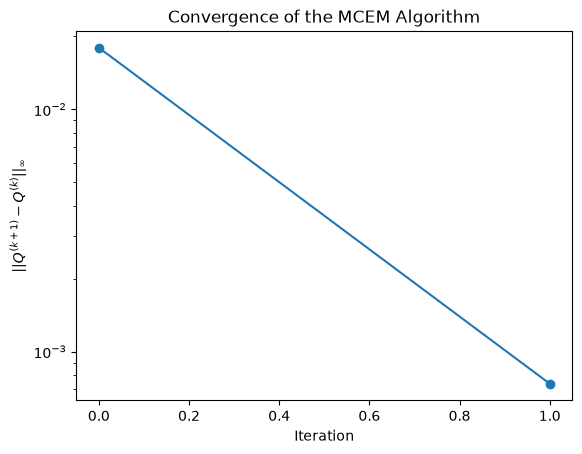

In [99]:
diffs = [np.max(np.abs(Q_history[i + 1] - Q_history[i])) for i in range(len(Q_history) - 1)]
plt.plot(diffs, marker='o')
plt.xlabel('Iteration')
plt.ylabel(r'$||Q^{(k+1)} - Q^{(k)}||_\infty$')
plt.yscale('log')
plt.title('Convergence of the MCEM Algorithm')
plt.show()
